## Notebook 02: Cross-Subject Exploration and Baseline Model Evaluation

### Objectives

* Explore and inspect the remaining subject datasets.
* Apply the same preprocessing pipeline developed for Subject 1.
* Evaluate how well the baseline Random Forest model generalizes to unseen subjects.

### Tasks Performed

* Loaded and analyzed datasets from additional subjects.
* Applied data cleaning and skeleton normalization.
* Checked class distributions and dataset consistency.
* Tested the Subject 1 baseline model on unseen subjects.
* Combined multiple subjects into a larger training dataset.
* Evaluated performance on a held-out subject.

### Key Findings

* The baseline model achieved very high performance during within-subject evaluation.
* Performance dropped significantly when evaluated on unseen subjects.
* Walking and Attacking generalized relatively well across subjects.
* Activities such as Biting, Using Phone, Eating Snacks, and Sitting Quietly were more difficult to distinguish.
* Results highlighted the challenge of subject-independent Human Activity Recognition (HAR).

### Outputs

* Classification reports
* Confusion matrices
* Cross-subject performance comparisons
* Initial observations for future feature engineering experiments

In [46]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [164]:
from har_utils.data import get_subject, get_clean_header
from har_utils.config import FILE_NAME_SUFFIX
from har_utils.preprocessing import (
    do_sanity_check, 
    preprocessing_pipeline
)
from har_utils.visualization import (
    plot_class_distribution,
    plot_compare_feature_side_by_side,
    plot_percentage_distribution,
    plot_compare_histograms,
    plot_confusion_matrix
)
from har_utils.model import model_random_forest
from har_utils.features import add_velocity_features
from har_utils.analysis import evaluate_random_forest

import joblib

import random as rnd

import pandas as pd

from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [162]:
# Importing all the subjects & printing their shapes
all_subject = {}
for suffix in FILE_NAME_SUFFIX:
    all_subject[suffix] = get_subject(suffix)
    print(f"Subject_{suffix} Shape: {all_subject[suffix].shape}")

1
Subject_1 Shape: (76456, 35)
2
Subject_2 Shape: (74638, 35)
3
Subject_3 Shape: (118087, 35)
5
Subject_5 Shape: (75981, 35)


In [49]:
# Perform Sanity Check on all subjects
for suffix in FILE_NAME_SUFFIX:
    do_sanity_check(all_subject[suffix], f"Subject_{suffix}")


____________________________________________________________

               Sanity Check - Subject_1
____________________________________________________________

NaN counts:
  Action Label: 3406

Inf counts:

____________________________________________________________

               Sanity Check - Subject_2
____________________________________________________________

NaN counts:
  Action Label: 3388

Inf counts:

____________________________________________________________

               Sanity Check - Subject_3
____________________________________________________________

NaN counts:
  Action Label: 11617

Inf counts:

____________________________________________________________

               Sanity Check - Subject_5
____________________________________________________________

NaN counts:
  Action Label: 4161

Inf counts:


In [166]:
# Skeleton normalize all subjects
all_subject_norm = {}
for suffix in FILE_NAME_SUFFIX:
    subject_name = f'SUBJECT_{suffix}'
    get_clean_header(subject_name)
    all_subject_norm[suffix] = preprocessing_pipeline(all_subject[suffix])
    print(f"Subject_{suffix} Shape: {all_subject_norm[suffix].shape}")
    print(f"Description of Subject_{suffix}:\n{all_subject_norm[suffix].describe().T.round(2)}")


                                   SUBJECT_1                                    
y hip corrected
Total Number of Bad Frames where shoulder widht was less than 10: 1377
Subject_1 Shape: (71673, 35)
Description of Subject_1:
                    count  mean   std    min   25%   50%   75%    max
nose_x            71673.0 -0.01  1.05 -12.24 -0.60  0.11  0.53   9.87
nose_y            71673.0 -2.62  1.82 -21.79 -2.80 -2.21 -1.71   3.03
left_eye_x        71673.0  0.01  1.06 -12.77 -0.59  0.18  0.52  10.46
left_eye_y        71673.0 -2.79  1.88 -22.89 -2.97 -2.37 -1.87   2.76
right_eye_x       71673.0 -0.15  1.06 -12.74 -0.71 -0.06  0.40  10.37
right_eye_y       71673.0 -2.74  1.88 -22.88 -2.93 -2.30 -1.81   2.84
left_ear_x        71673.0 -0.12  0.88 -12.02 -0.63  0.05  0.31   9.87
left_ear_y        71673.0 -2.83  1.81 -22.49 -3.03 -2.41 -1.91   2.20
right_ear_x       71673.0 -0.46  0.91 -11.41 -0.88 -0.34 -0.06  10.37
right_ear_y       71673.0 -2.67  1.82 -22.47 -2.88 -2.19 -1.77   1.73
left_s

### Let's test the model trained on Subject_1 using Subject_2

In [145]:
X_subject2 = all_subject_norm[FILE_NAME_SUFFIX[1]].drop(columns=['Action Label'])
X_subject2.head()

,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,left_ear_x,left_ear_y,right_ear_x,right_ear_y,...,right_hip_x,right_hip_y,left_knee_x,left_knee_y,right_knee_x,right_knee_y,left_ankle_x,left_ankle_y,right_ankle_x,right_ankle_y
frame_id,,,,,,,,,,,,,,,,,,,,,
0,-0.351865,-2.055635,-0.267206,-2.166750,-0.473563,-2.148231,-0.129635,-2.135003,-0.658756,-2.092673,...,-0.314827,0.050266,0.558223,1.007975,-0.161382,1.113799,0.589970,1.992140,-0.087305,2.002723
1,-0.309822,-2.060185,-0.230381,-2.171403,-0.436929,-2.150218,-0.113866,-2.150218,-0.632884,-2.099905,...,-0.309822,0.050313,0.564035,1.003612,-0.166827,1.109534,0.648773,1.999279,-0.092682,2.009872
2,-0.283248,-2.076264,-0.208428,-2.188494,-0.411512,-2.167117,-0.101542,-2.156429,-0.619940,-2.108330,...,-0.315314,0.048099,0.582530,1.020763,-0.187051,1.116961,0.710793,2.041526,-0.112230,2.014804
3,-0.260989,-2.077262,-0.175768,-2.189114,-0.388821,-2.170472,-0.069242,-2.157156,-0.591221,-2.111883,...,-0.314252,0.042610,0.580568,1.022652,-0.207726,1.113199,0.719052,2.039977,-0.154463,1.997367
4,-0.225286,-2.097306,-0.150191,-2.209949,-0.354021,-2.191176,-0.053640,-2.177766,-0.573943,-2.134854,...,-0.311109,0.042912,0.579307,1.024515,-0.236014,1.121067,0.686586,2.043667,-0.193102,2.011483


In [56]:
y_subject2 = all_subject_norm[FILE_NAME_SUFFIX[1]]['Action Label']
y_subject2

frame_id
0          Walking
1          Walking
2          Walking
3          Walking
4          Walking
           ...    
74575    Attacking
74576    Attacking
74577    Attacking
74578    Attacking
74579    Attacking
Name: Action Label, Length: 70356, dtype: str

In [57]:
# Importing the model
rf = joblib.load(
    "random_forest_subject_one.pkl"
)
predictions = rf.predict(X_subject2)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.2s finished


In [58]:
print(
    classification_report(
        y_subject2,
        predictions
    )
)

                 precision    recall  f1-score   support

      Attacking       0.12      0.27      0.16      5719
         Biting       0.00      0.00      0.00      2790
  Eating snacks       0.00      0.00      0.00     14670
   Head banging       0.01      0.01      0.01      3930
Sitting quietly       0.00      0.00      0.00     14700
Throwing things       0.45      0.18      0.26      3950
    Using phone       0.00      0.00      0.00     10980
        Walking       0.32      0.93      0.48     13617

       accuracy                           0.21     70356
      macro avg       0.11      0.17      0.11     70356
   weighted avg       0.10      0.21      0.12     70356



/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

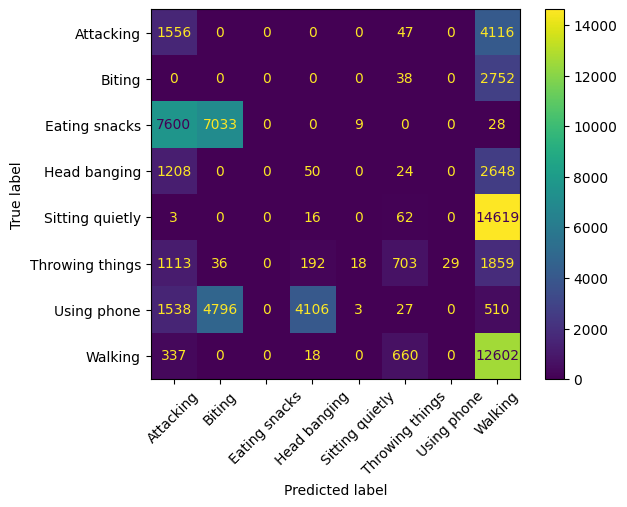

In [59]:
ConfusionMatrixDisplay.from_predictions(
    y_subject2,
    predictions,
    xticks_rotation=45
)

# Visual Analysis

### Feature Comparison: Before and After Normalization

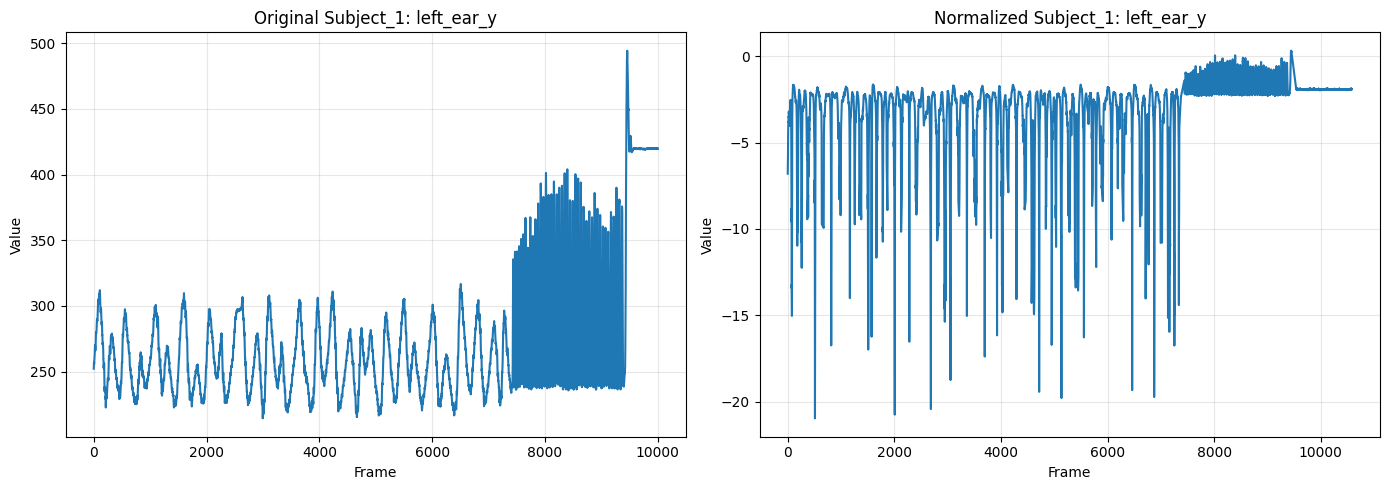

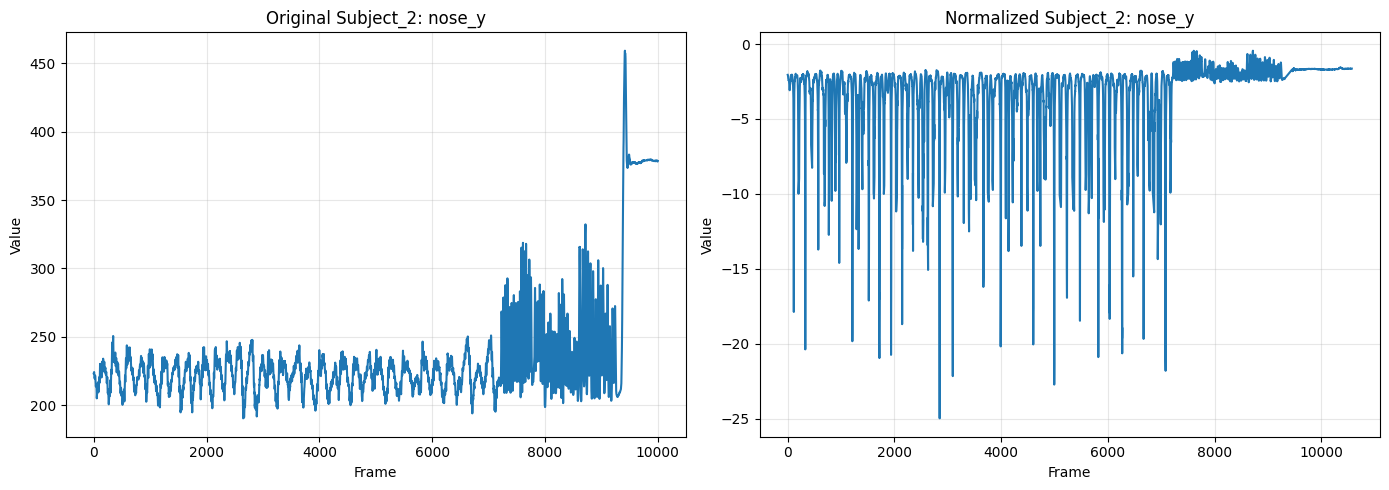

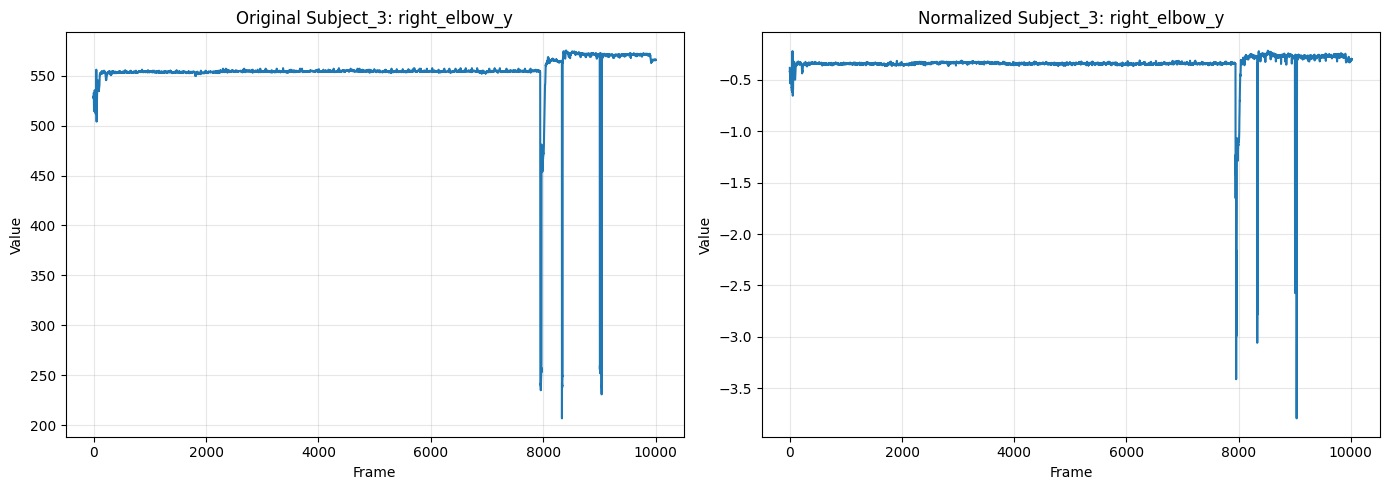

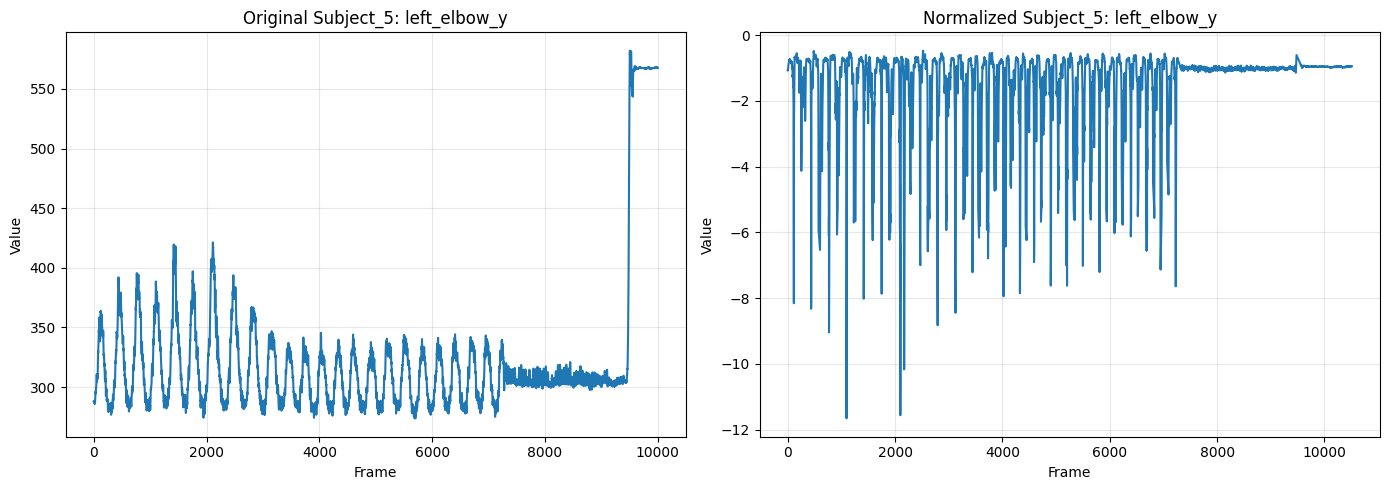

In [146]:
rnd.seed(42)

feature_cols = [col for col in all_subject[FILE_NAME_SUFFIX[0]].columns if col != 'Action Label']

for suffix in FILE_NAME_SUFFIX:
    rnd_feature = rnd.choice(feature_cols)
    plot_compare_feature_side_by_side(
        all_subject[suffix], # Original DF
        all_subject_norm[suffix]
        , # Transformed DF
        rnd_feature,
        f"Subject_{suffix}",
        start=0,
        end=10000
    )
    print('\n\n')

### Class Distribution for all subject

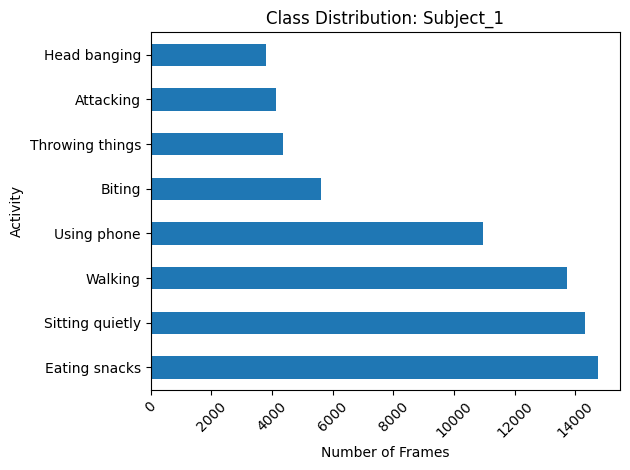

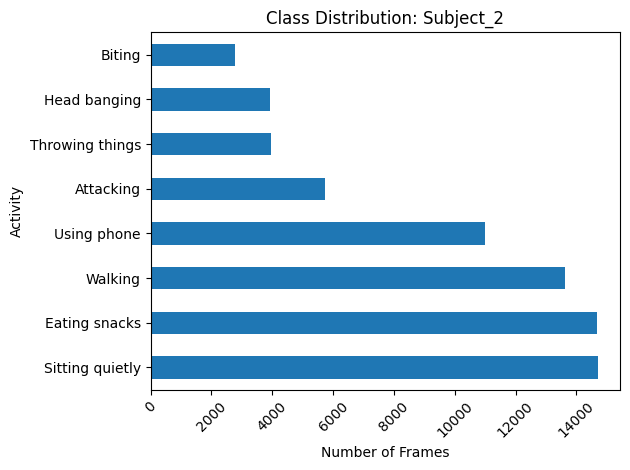

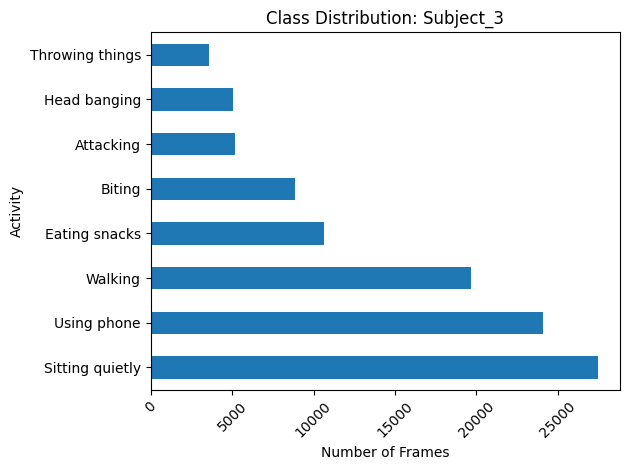

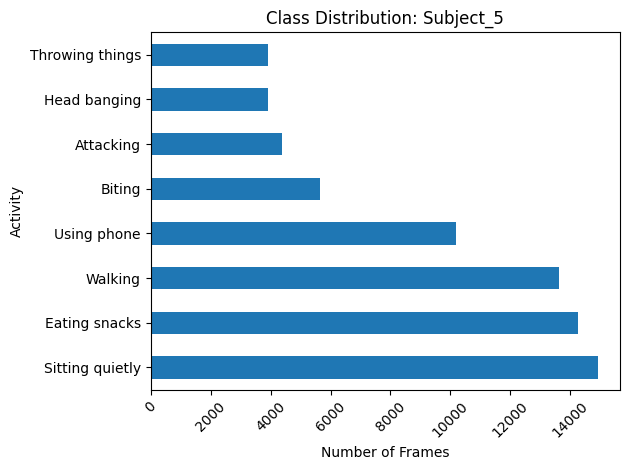

In [147]:
for suffix in FILE_NAME_SUFFIX:
    plot_class_distribution(all_subject_norm[suffix], f'Subject_{suffix}')
    print('\n\n')

### Percentage Distribution

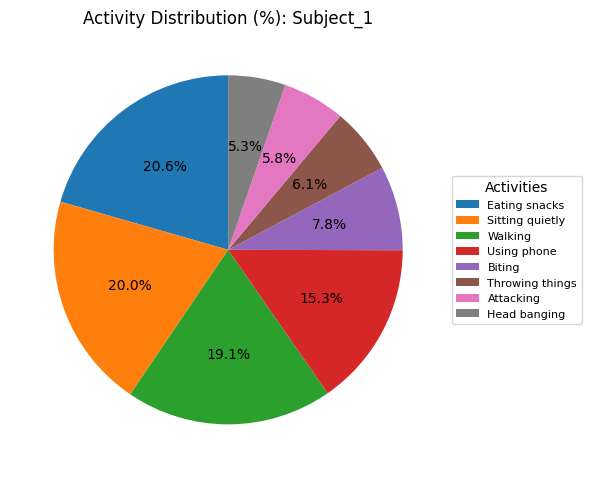

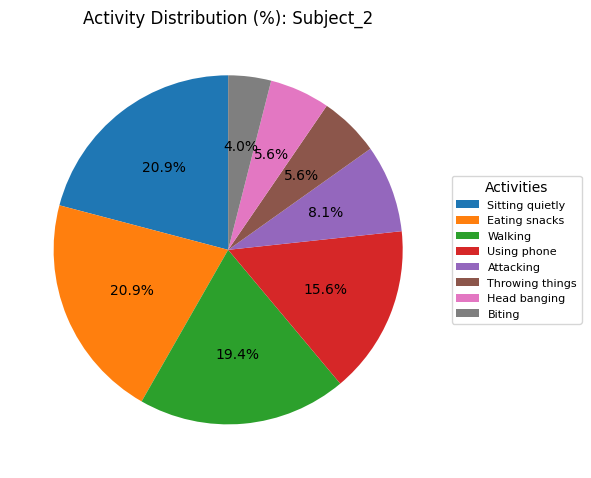

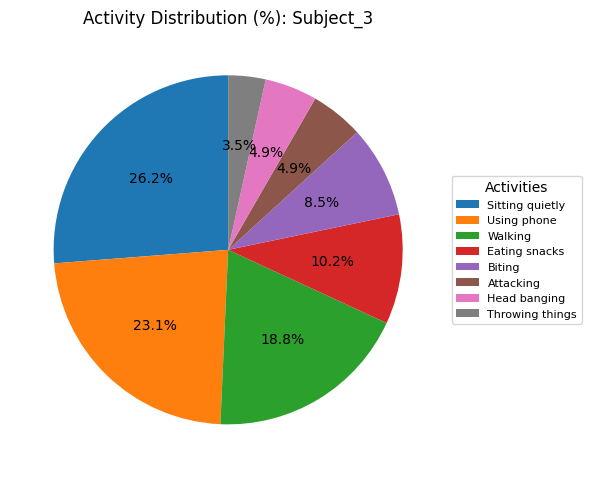

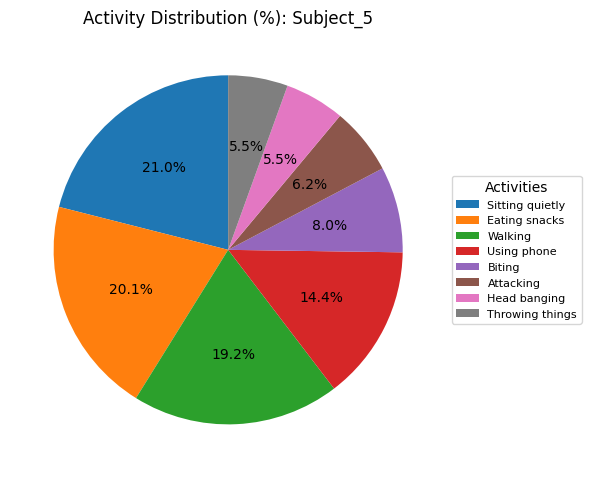

In [148]:
for suffix in FILE_NAME_SUFFIX:
    plot_percentage_distribution(all_subject_norm[suffix], f'Subject_{suffix}')
    print('\n\n')

## Let's combine Subject 1, 2 and 3

In [149]:
train = pd.concat(list(all_subject_norm.values())[:3])

test = all_subject_norm[FILE_NAME_SUFFIX[-1]]

In [150]:
X_train = train.drop(
    columns=['Action Label']
)

y_train = train['Action Label']

X_test = test.drop(
    columns=['Action Label']
)

y_test = test['Action Label']
print(f"Shape of X_train:{X_train.shape}")
print(f"Shape of X_test:{X_test.shape}")
print(f"Shape of y_train:{y_train.shape}")
print(f"Shape of y_test:{y_test.shape}")

Shape of X_train:(246613, 34)
Shape of X_test:(70863, 34)
Shape of y_train:(246613,)
Shape of y_test:(70863,)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   11.7s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   31.3s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished


                 precision    recall  f1-score   support

      Attacking       0.89      0.66      0.76      4392
         Biting       0.00      0.00      0.00      5640
  Eating snacks       0.34      1.00      0.50     14250
   Head banging       0.88      0.07      0.13      3930
Sitting quietly       0.00      0.00      0.00     14910
Throwing things       0.62      0.68      0.65      3916
    Using phone       0.47      0.00      0.00     10200
        Walking       0.75      0.99      0.85     13625

       accuracy                           0.47     70863
      macro avg       0.49      0.42      0.36     70863
   weighted avg       0.42      0.47      0.36     70863






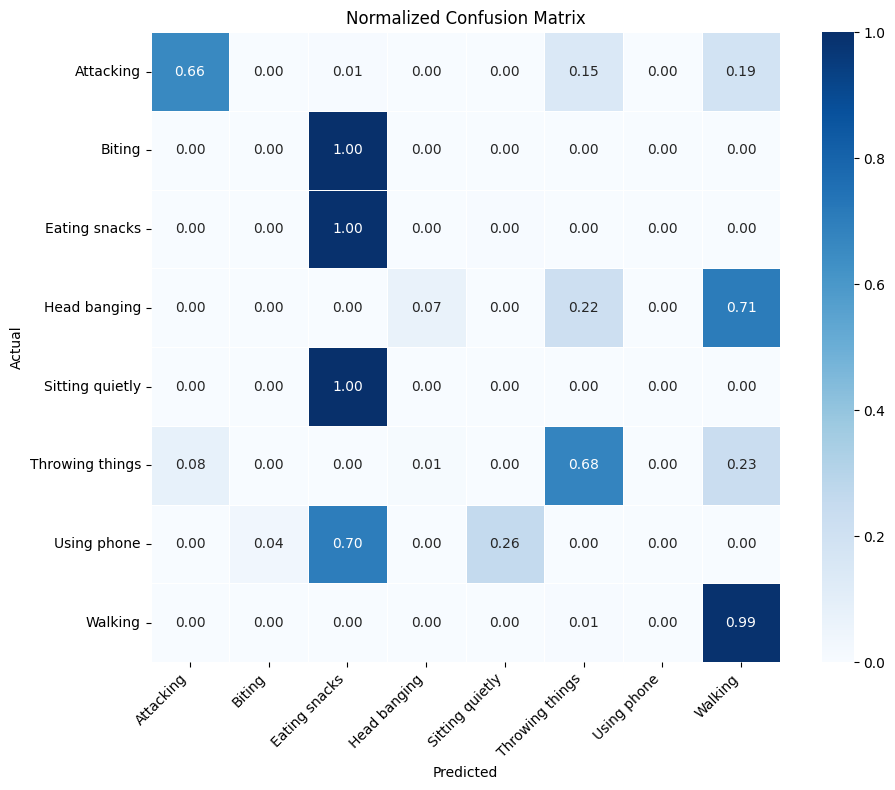

array(['Walking', 'Walking', 'Walking', ..., 'Walking', 'Walking',
       'Walking'], shape=(70863,), dtype=object)

In [151]:
evaluate_random_forest(X_train, y_train, X_test, y_test)

# Let's us add velocity feature 

In [157]:
# Adding the velocity features and dropping the NaN column
X_train_vel = add_velocity_features(X_train).iloc[1:]
X_test_vel = add_velocity_features(X_test).iloc[1:]
print(f"Shape of X_train:{X_train_velocity.shape}")
print(f"Shape of X_test:{X_test_velocity.shape}\n\n")
print(f"X_train:\n{X_train_velocity.describe().T.round(2)}\n\n")
print(f"X_test:\n{X_test_velocity.describe().T.round(2)}")

Shape of X_train:(246612, 68)
Shape of X_test:(70862, 68)


X_train:
                      count  mean   std    min   25%   50%   75%    max
nose_x             246612.0 -0.15  0.96 -12.24 -0.29 -0.11  0.12  12.11
nose_y             246612.0 -2.34  2.13 -37.30 -2.38 -1.79 -1.45   3.03
left_eye_x         246612.0 -0.08  0.94 -12.77 -0.20 -0.02  0.19  12.15
left_eye_y         246612.0 -2.48  2.22 -38.69 -2.52 -1.90 -1.55   2.76
right_eye_x        246612.0 -0.26  0.95 -12.74 -0.38 -0.21 -0.02  11.44
...                     ...   ...   ...    ...   ...   ...   ...    ...
right_knee_y_vel   246612.0 -0.00  0.31 -10.30 -0.01  0.00  0.01  11.62
left_ankle_x_vel   246612.0  0.00  0.19 -10.51 -0.01  0.00  0.01   7.34
left_ankle_y_vel   246612.0 -0.00  0.55 -18.29 -0.01  0.00  0.01  18.53
right_ankle_x_vel  246612.0 -0.00  0.22  -7.94 -0.01  0.00  0.01   8.78
right_ankle_y_vel  246612.0 -0.00  0.58 -19.26 -0.01  0.00  0.01  19.85

[68 rows x 8 columns]


X_test:
                     count  mean  

In [158]:
y_train_vel = y_train.iloc[1:]
y_test_vel = y_test.iloc[1:]
print(f"Shape of X_train:{X_train_velocity.shape}")
print(f"Shape of X_test:{X_test_velocity.shape}")
print(f"Shape of y_train:{y_train_vel.shape}")
print(f"Shape of y_test:{y_test_vel.shape}")

Shape of X_train:(246612, 68)
Shape of X_test:(70862, 68)
Shape of y_train:(246612,)
Shape of y_test:(70862,)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   23.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   55.8s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished


                 precision    recall  f1-score   support

      Attacking       0.89      0.72      0.79      4392
         Biting       0.00      0.00      0.00      5640
  Eating snacks       0.31      0.99      0.48     14250
   Head banging       0.90      0.09      0.16      3930
Sitting quietly       0.00      0.00      0.00     14910
Throwing things       0.69      0.69      0.69      3916
    Using phone       0.36      0.00      0.00     10200
        Walking       0.75      0.99      0.85     13624

       accuracy                           0.48     70862
      macro avg       0.49      0.43      0.37     70862
   weighted avg       0.40      0.48      0.36     70862






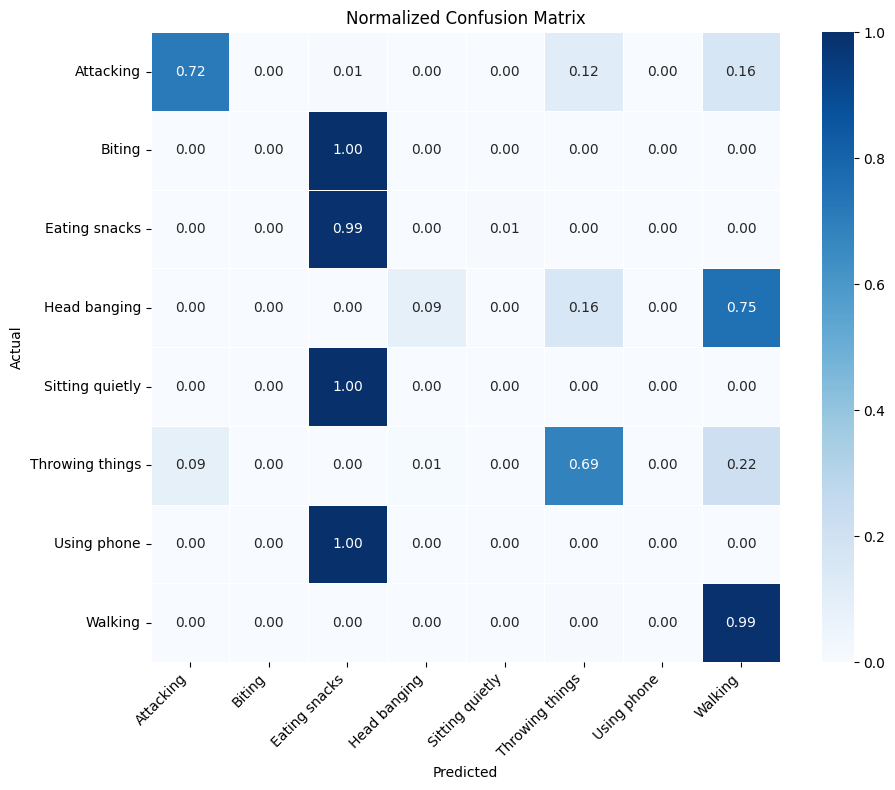

In [159]:
# Let's train a random forest model again
pred_vel = evaluate_random_forest(X_train_vel, y_train_vel, X_test_vel, y_test_vel)

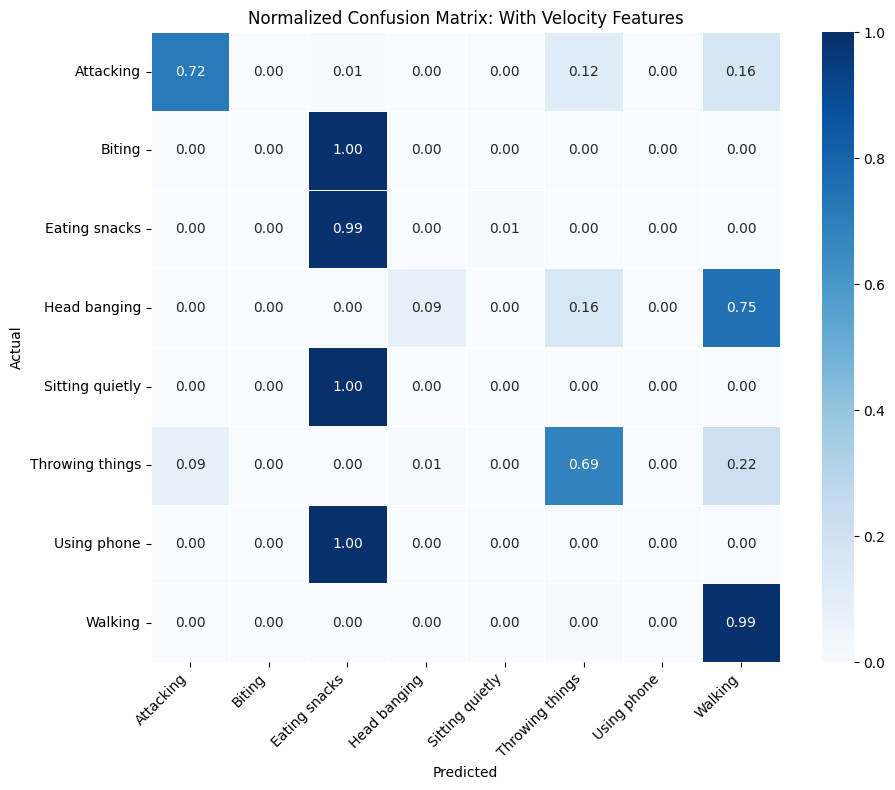

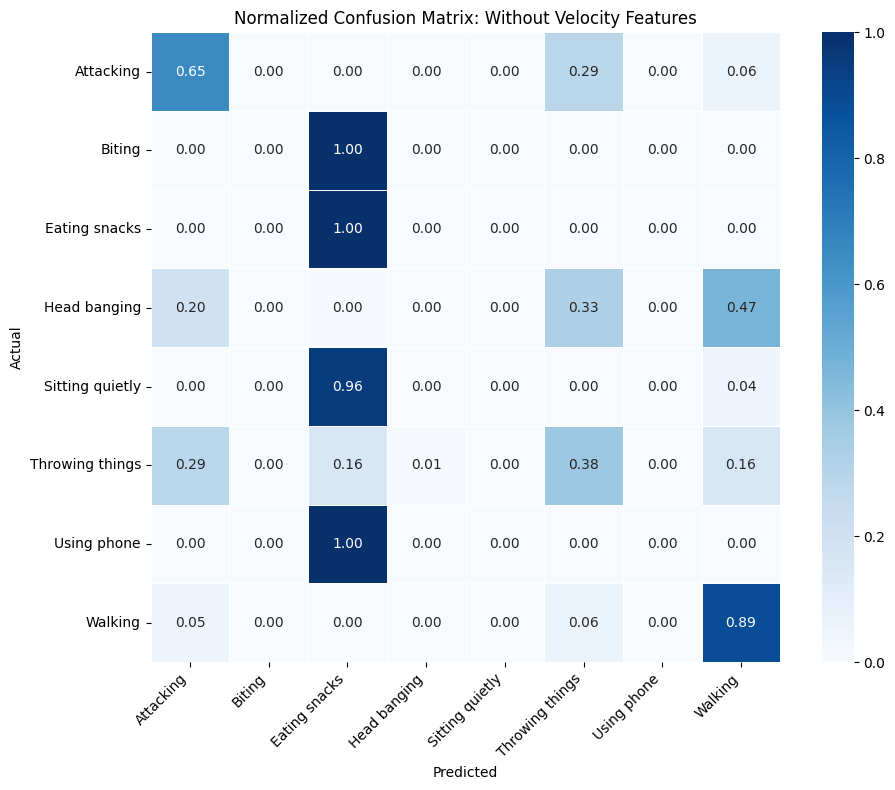

In [160]:
plot_confusion_matrix(y_test_vel, pred_vel, "Normalized Confusion Matrix: With Velocity Features")
plot_confusion_matrix(y_test, pred, "Normalized Confusion Matrix: Without Velocity Features")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   12.4s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   30.7s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predi

                 precision    recall  f1-score   support

      Attacking       0.52      0.65      0.58      4392
         Biting       0.00      0.00      0.00      5640
  Eating snacks       0.32      1.00      0.48     14250
   Head banging       0.00      0.00      0.00      3930
Sitting quietly       0.00      0.00      0.00     14910
Throwing things       0.31      0.38      0.34      3916
    Using phone       0.00      0.00      0.00     10200
        Walking       0.78      0.89      0.83     13625

       accuracy                           0.43     70863
      macro avg       0.24      0.37      0.28     70863
   weighted avg       0.26      0.43      0.31     70863






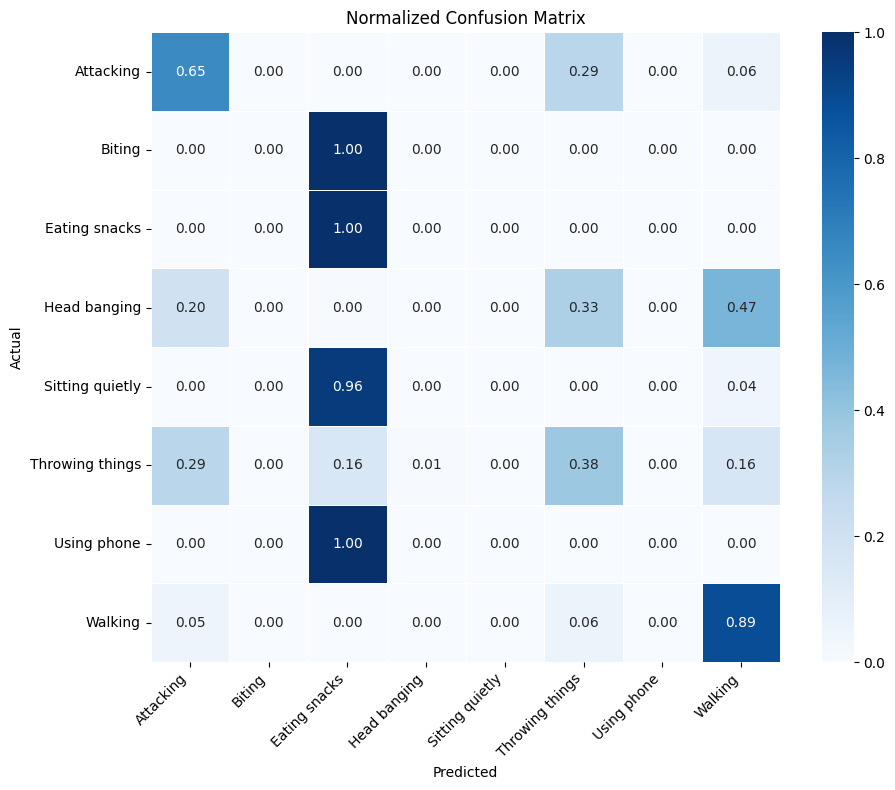

array(['Walking', 'Walking', 'Walking', ..., 'Walking', 'Walking',
       'Walking'], shape=(70863,), dtype=object)

In [140]:
# Without weighted class
evaluate_random_forest(X_train, y_train, X_test, y_test)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   11.9s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   33.6s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished


                 precision    recall  f1-score   support

      Attacking       0.52      0.65      0.58      4392
         Biting       0.00      0.00      0.00      5640
  Eating snacks       0.32      1.00      0.48     14250
   Head banging       0.00      0.00      0.00      3930
Sitting quietly       0.00      0.00      0.00     14910
Throwing things       0.31      0.38      0.34      3916
    Using phone       0.00      0.00      0.00     10200
        Walking       0.78      0.89      0.83     13625

       accuracy                           0.43     70863
      macro avg       0.24      0.37      0.28     70863
   weighted avg       0.26      0.43      0.31     70863






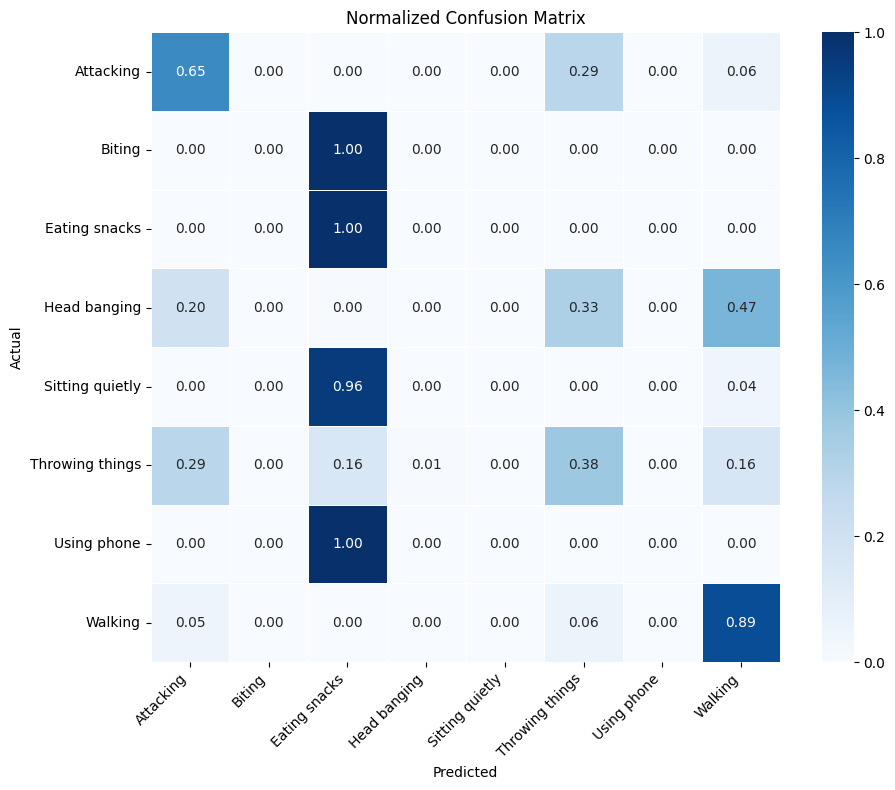

In [143]:
# With Weighted class
pred = evaluate_random_forest(X_train, y_train, X_test, y_test)

In [142]:
pd.Series(pred).value_counts()

Eating snacks      44946
Walking            15495
Attacking           5512
Throwing things     4868
Head banging          35
Sitting quietly        7
Name: count, dtype: int64